In [9]:
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()

np.random.seed(42)

incident_types = [
    "Phishing",
    "Malware",
    "DDoS",
    "Ransomware",
    "Insider Threat",
    "SQL Injection"
]

severity_levels = ["Low", "Medium", "High", "Critical"]

statuses = ["Open", "Investigating", "Resolved"]

departments = ["Finance", "IT", "HR", "Operations", "Sales"]

records = []

for i in range(500):

    incident_date = fake.date_between(start_date='-1y', end_date='today')

    incident = {
        "incident_id": i + 1,
        "company_name": fake.company(),
        "incident_type": random.choice(incident_types),
        "severity": random.choice(severity_levels),
        "department": random.choice(departments),
        "affected_users": random.randint(5, 500),
        "financial_loss_usd": random.randint(1000, 100000),
        "resolution_time_hours": random.randint(1, 72),
        "status": random.choice(statuses),
        "incident_date": incident_date
    }

    records.append(incident)

df = pd.DataFrame(records)

df.head()

,incident_id,company_name,incident_type,severity,department,affected_users,financial_loss_usd,resolution_time_hours,status,incident_date
0,1,Torres-Alexander,Insider Threat,High,HR,441,16110,55,Investigating,2025-07-13
1,2,"Norton, Sanders and Smith",SQL Injection,High,HR,386,69464,64,Resolved,2026-01-01
2,3,Palmer-Tran,Phishing,Critical,HR,384,92024,40,Open,2025-05-26
3,4,Allen-Ward,Insider Threat,Critical,IT,262,83928,9,Investigating,2026-01-07
4,5,Cannon and Sons,DDoS,Critical,Finance,369,66317,35,Investigating,2025-10-05


In [10]:
df.to_csv("../data/cybersecurity_incidents.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   incident_id            500 non-null    int64 
 1   company_name           500 non-null    str   
 2   incident_type          500 non-null    str   
 3   severity               500 non-null    str   
 4   department             500 non-null    str   
 5   affected_users         500 non-null    int64 
 6   financial_loss_usd     500 non-null    int64 
 7   resolution_time_hours  500 non-null    int64 
 8   status                 500 non-null    str   
 9   incident_date          500 non-null    object
dtypes: int64(4), object(1), str(5)
memory usage: 61.4+ KB


In [12]:
df["incident_type"].value_counts()

incident_type
Insider Threat    98
Ransomware        91
Phishing          90
DDoS              80
SQL Injection     71
Malware           70
Name: count, dtype: int64

NameError: name 'plt' is not defined

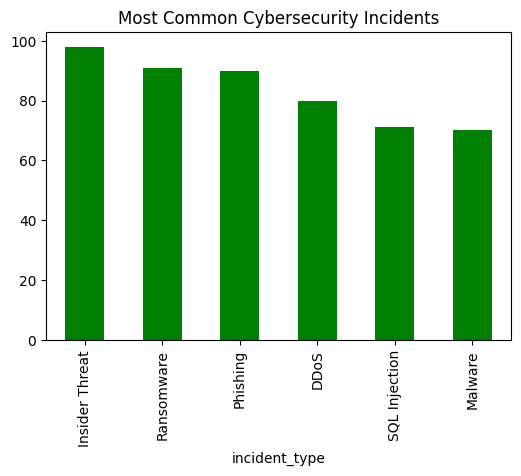

In [13]:
incident_counts = df["incident_type"].value_counts()

ax = incident_counts.plot(
    kind="bar",
    color="green",
    figsize=(6,4),
    title="Most Common Cybersecurity Incidents"
)

plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() + 1,
        str(int(i.get_height())),
        ha='center'
    )

plt.show()

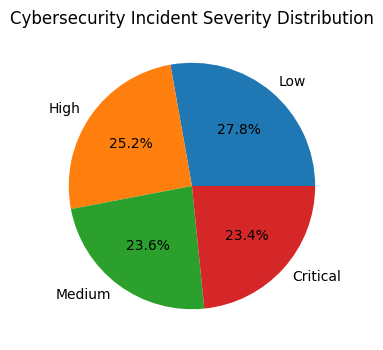

In [ ]:
import matplotlib.pyplot as plt
severity_counts = df["severity"].value_counts()

severity_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(10,4),
    title="Cybersecurity Incident Severity Distribution"
)

plt.ylabel("")
plt.show()

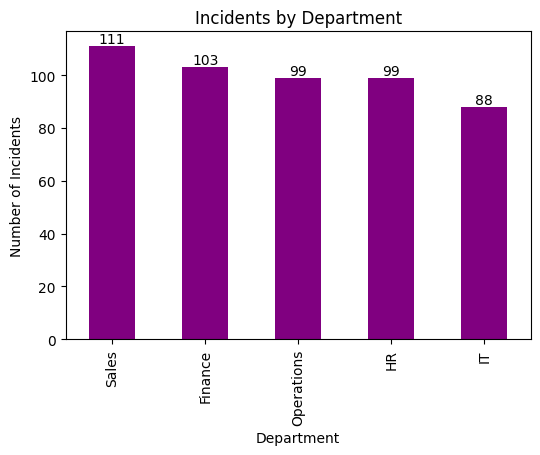

In [ ]:
department_counts = df["department"].value_counts()

ax = department_counts.plot(
    kind="bar",
    color="purple",
    figsize=(6,4),
    title="Incidents by Department"
)

plt.xlabel("Department")
plt.ylabel("Number of Incidents")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() + 1,
        str(int(i.get_height())),
        ha='center'
    )

plt.show()

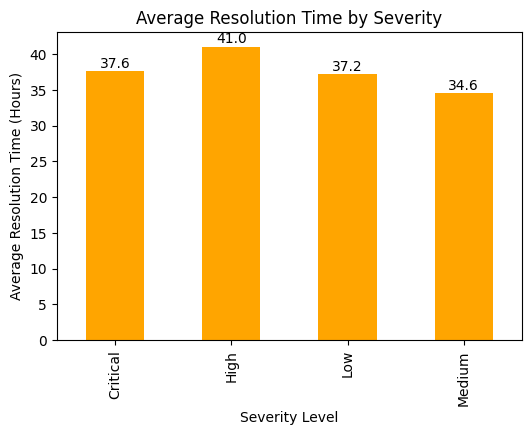

In [ ]:
resolution_time = df.groupby("severity")["resolution_time_hours"].mean()

ax = resolution_time.plot(
    kind="bar",
    color="orange",
    figsize=(6,4),
    title="Average Resolution Time by Severity"
)

plt.xlabel("Severity Level")
plt.ylabel("Average Resolution Time (Hours)")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() + 0.5,
        round(i.get_height(), 1),
        ha='center'
    )

plt.show()

In [ ]:
df["incident_date"] = pd.to_datetime(df["incident_date"])

df["incident_date"].head()

0   2025-09-17
1   2025-08-16
2   2026-04-02
3   2025-05-13
4   2026-04-09
Name: incident_date, dtype: datetime64[s]

In [ ]:
monthly_incidents = df.groupby(
    df["incident_date"].dt.month
)["incident_id"].count()

monthly_incidents

incident_date
1     38
2     44
3     44
4     31
5     39
6     39
7     44
8     42
9     62
10    34
11    42
12    41
Name: incident_id, dtype: int64

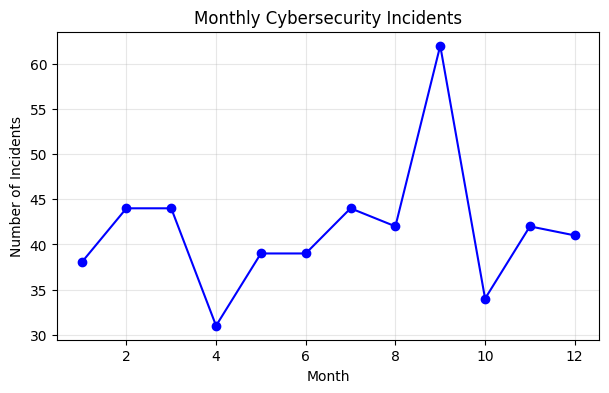

In [ ]:
ax = monthly_incidents.plot(
    kind="line",
    marker="o",
    color="blue",
    figsize=(7,4),
    title="Monthly Cybersecurity Incidents"
)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.grid(alpha=0.3)

plt.show()

## SQL Analysis

In [14]:
import sqlite3

In [15]:
conn = sqlite3.connect("../sql/cybersecurity_incidents.db")

conn

In [16]:
df.to_sql(
    "incidents",
    conn,
    if_exists="replace",
    index=False
)

print("Data loaded into SQL database successfully!")

Data loaded into SQL database successfully!


In [17]:
query = """
SELECT incident_type,
COUNT(*) AS total_incidents
FROM incidents
GROUP BY incident_type
ORDER BY total_incidents DESC
"""

sql_result = pd.read_sql(query, conn)

sql_result

,incident_type,total_incidents
0,Insider Threat,98
1,Ransomware,91
2,Phishing,90
3,DDoS,80
4,SQL Injection,71
5,Malware,70


In [19]:
import matplotlib.pyplot as plt

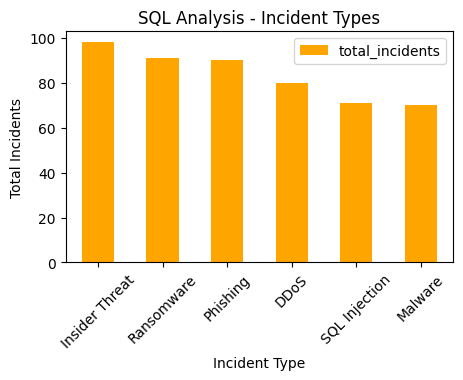

In [22]:
sql_result.plot(
    x="incident_type",
    y="total_incidents",
    kind="bar",
    color="orange",
    figsize=(5,3),
    title="SQL Analysis - Incident Types"
)

plt.xlabel("Incident Type")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)

plt.show()

<Figure size 500x300 with 0 Axes>

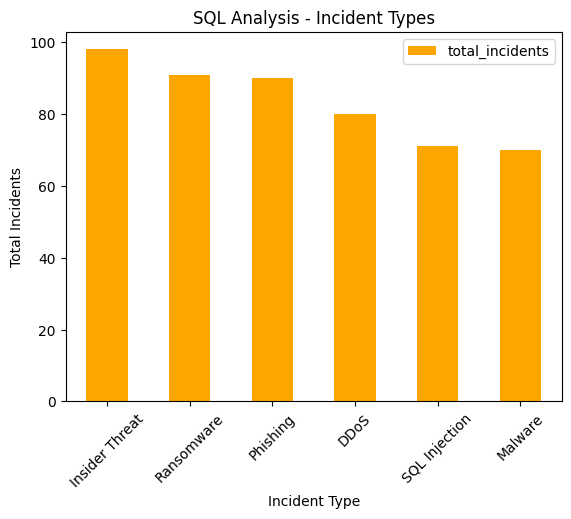

In [23]:
plt.figure(figsize=(5,3))

sql_result.plot(
    x="incident_type",
    y="total_incidents",
    kind="bar",
    color="orange"
)

plt.title("SQL Analysis - Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)

plt.savefig("../images/sql_incident_chart.png")

plt.show()

In [24]:
query2 = """
SELECT department,
SUM(financial_loss_usd) AS total_loss
FROM incidents
GROUP BY department
ORDER BY total_loss DESC
"""

loss_result = pd.read_sql(query2, conn)

loss_result

,department,total_loss
0,Operations,5741878
1,HR,5357695
2,Sales,5239226
3,Finance,4739186
4,IT,4513371


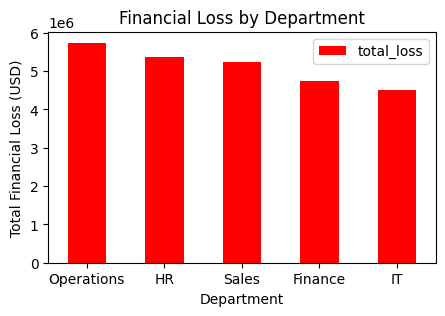

In [25]:
loss_result.plot(
    x="department",
    y="total_loss",
    kind="bar",
    color="red",
    figsize=(5,3),
    title="Financial Loss by Department"
)

plt.xlabel("Department")
plt.ylabel("Total Financial Loss (USD)")
plt.xticks(rotation=0)

plt.show()

In [26]:
query3 = """
SELECT company_name,
incident_type,
financial_loss_usd
FROM incidents
ORDER BY financial_loss_usd DESC
LIMIT 5
"""

top_loss_cases = pd.read_sql(query3, conn)

top_loss_cases

,company_name,incident_type,financial_loss_usd
0,Mcdowell-Mcdaniel,Ransomware,99715
1,Kim-Parker,Ransomware,99363
2,"Jacobson, Pacheco and Small",Malware,98859
3,Burke Inc,Malware,98586
4,Adams-Smith,DDoS,98522


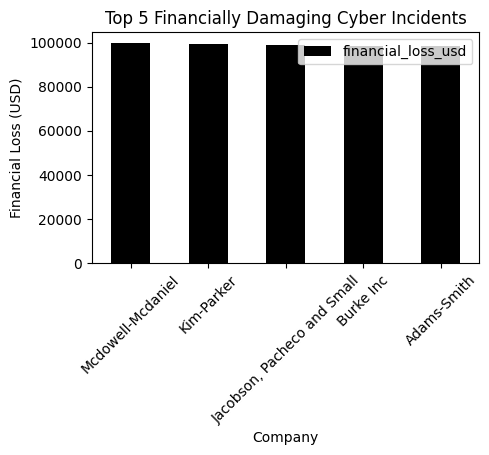

In [41]:
top_loss_cases.plot(
    x="company_name",
    y="financial_loss_usd",
    kind="bar",
    color="black",
    figsize=(5,3),
    title="Top 5 Financially Damaging Cyber Incidents"
)

plt.xlabel("Company")
plt.ylabel("Financial Loss (USD)")
plt.xticks(rotation=45)

plt.show()

In [34]:
query4 = """
SELECT incident_type,
COUNT(*) AS critical_incidents
FROM incidents
WHERE severity = 'Critical'
GROUP BY incident_type
ORDER BY critical_incidents DESC
"""

critical_result = pd.read_sql(query4, conn)

critical_result

,incident_type,critical_incidents
0,Phishing,31
1,Ransomware,26
2,SQL Injection,24
3,Malware,21
4,Insider Threat,19
5,DDoS,15


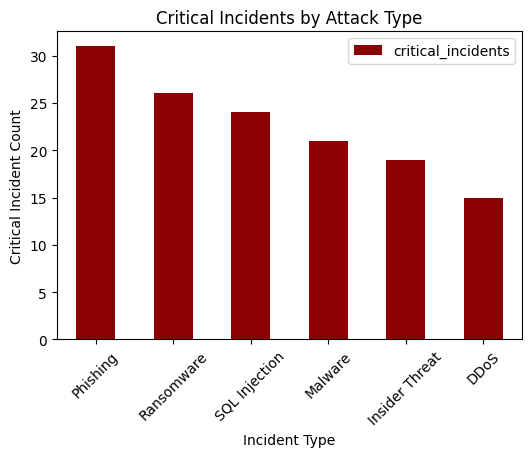

In [39]:
critical_result.plot(
    x="incident_type",
    y="critical_incidents",
    kind="bar",
    color="darkred",
    figsize=(6,4),
    title="Critical Incidents by Attack Type"
)

plt.xlabel("Incident Type")
plt.ylabel("Critical Incident Count")
plt.xticks(rotation=45)

plt.show()

In [36]:
query5 = """
SELECT incident_type,
AVG(resolution_time_hours) AS avg_resolution_time
FROM incidents
GROUP BY incident_type
ORDER BY avg_resolution_time DESC
"""

resolution_result = pd.read_sql(query5, conn)

resolution_result

,incident_type,avg_resolution_time
0,Insider Threat,41.112245
1,SQL Injection,40.394366
2,Malware,39.285714
3,Ransomware,38.010989
4,DDoS,37.262500
5,Phishing,35.055556


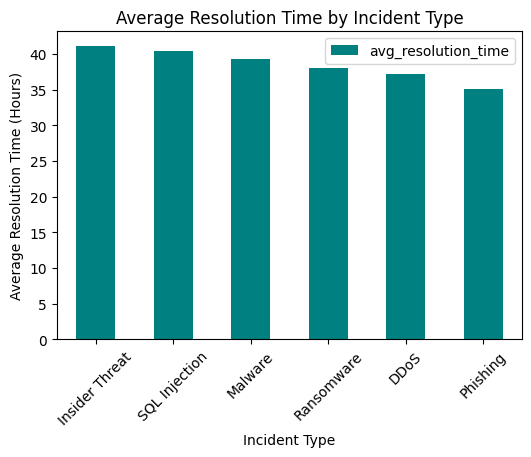

In [38]:
resolution_result.plot(
    x="incident_type",
    y="avg_resolution_time",
    kind="bar",
    color="teal",
    figsize=(6,4),
    title="Average Resolution Time by Incident Type"
)

plt.xlabel("Incident Type")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=45)

plt.show()

In [42]:
query6 = """
SELECT status,
COUNT(*) AS total_incidents
FROM incidents
GROUP BY status
"""

status_result = pd.read_sql(query6, conn)

status_result

,status,total_incidents
0,Investigating,181
1,Open,159
2,Resolved,160


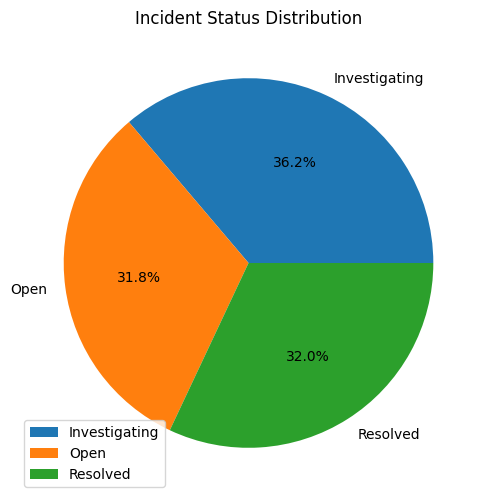

In [47]:
status_result.plot(
    kind="pie",
    y="total_incidents",
    labels=status_result["status"],
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Incident Status Distribution"
)

plt.ylabel("")
plt.show()

In [48]:
query7 = """
SELECT company_name,
SUM(financial_loss_usd) AS total_loss
FROM incidents
GROUP BY company_name
ORDER BY total_loss DESC
LIMIT 10
"""

company_loss_result = pd.read_sql(query7, conn)

company_loss_result

,company_name,total_loss
0,Castillo Group,129352
1,Smith Ltd,112844
2,Miller Inc,100950
3,Mcdowell-Mcdaniel,99715
4,Kim-Parker,99363
5,"Jacobson, Pacheco and Small",98859
6,Burke Inc,98586
7,Adams-Smith,98522
8,"Price, Morgan and Fields",98502
9,Hays PLC,98243


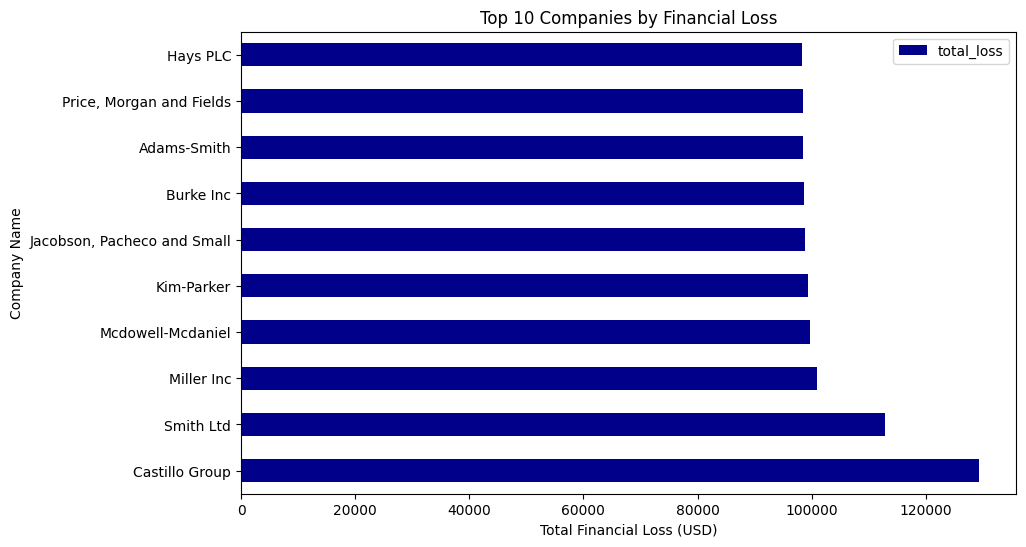

In [49]:
company_loss_result.plot(
    x="company_name",
    y="total_loss",
    kind="barh",
    color="darkblue",
    figsize=(10,6),
    title="Top 10 Companies by Financial Loss"
)

plt.xlabel("Total Financial Loss (USD)")
plt.ylabel("Company Name")

plt.show()

In [50]:
df.to_csv("../data/cybersecurity_incidents.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


# Python Analysis

- Generated a synthetic cybersecurity incident dataset using Python libraries such as Pandas, NumPy, Faker, and Random.
- Performed data cleaning and preprocessing to prepare the dataset for analysis.
- Conducted exploratory data analysis (EDA) to identify patterns in incident severity, departments, financial losses, and monthly trends.
- Created multiple visualizations using Matplotlib to analyze:
  - Incident severity distribution
  - Department-wise incident counts
  - Financial loss by incident type
  - Monthly cybersecurity incident trends
- Exported the processed dataset into CSV format for SQL and Power BI analysis.

# SQL Analysis

- Imported the cybersecurity dataset into an SQLite database using Python and SQLite3.
- Created and managed SQL tables for cybersecurity incident analysis.
- Executed SQL queries to analyze:
  - Most common incident types
  - Department-wise incident counts
  - Total financial losses by incident category
  - Incident severity distribution
  - Monthly incident trends
- Used SQL aggregation functions such as:
  - COUNT()
  - SUM()
  - GROUP BY
  - ORDER BY
- Retrieved query outputs for further visualization and dashboard creation in Power BI.